In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import quantstats as qs
import numpy as np

# Law of One Price Arbitrage

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Text(0, 0.5, 'Spread ($)')

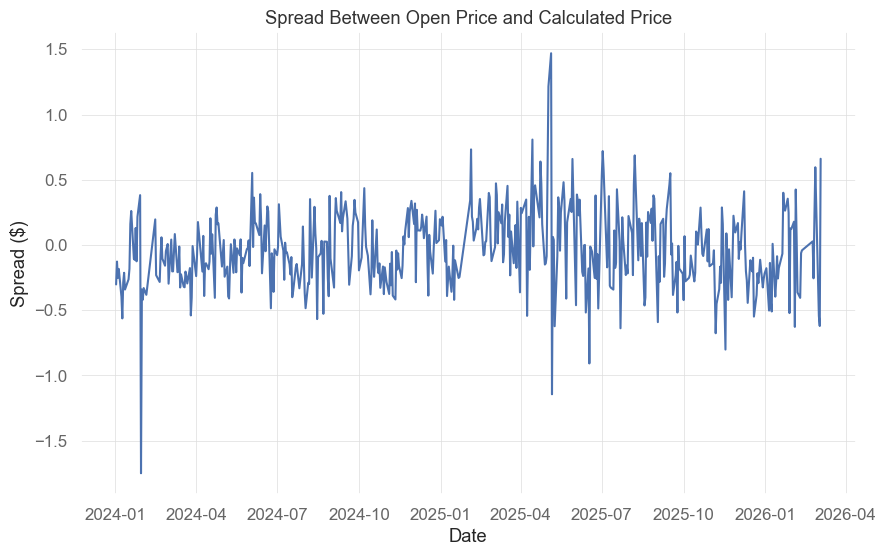

In [47]:
tw_ticker = "2412.TW"
us_ticker = "CHT"

tw_data = yf.download(tw_ticker, start="2024-01-01", end="2026-03-05", auto_adjust=True)
us_data = yf.download(us_ticker, start="2024-01-01", end="2026-03-05", auto_adjust=True)
fx_data = yf.download("TWDUSD=X", start="2024-01-01", end="2026-03-05", auto_adjust=True)

tw_data.columns = tw_data.columns.get_level_values(0)
us_data.columns = us_data.columns.get_level_values(0)
fx_data.columns = fx_data.columns.get_level_values(0)
tw_df = pd.DataFrame({
    'TW_Close': tw_data['Close'],
    'US_Open': us_data['Open'],
    'FX': fx_data['Close'],
    'US_High': us_data["High"],
    'US_Low': us_data["Low"],
    'US_Close': us_data['Close']
}).dropna()
tw_df['Fair_Value_USD'] = (tw_df['TW_Close'] * 10) * tw_df['FX']
tw_df['Spread TW - US'] = tw_df['US_Open'] - tw_df['Fair_Value_USD']



plt.plot(tw_df["Spread TW - US"])
plt.title("Spread Between Open Price and Calculated Price")
plt.xlabel("Date")
plt.ylabel("Spread ($)")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Text(0, 0.5, 'Spread ($)')

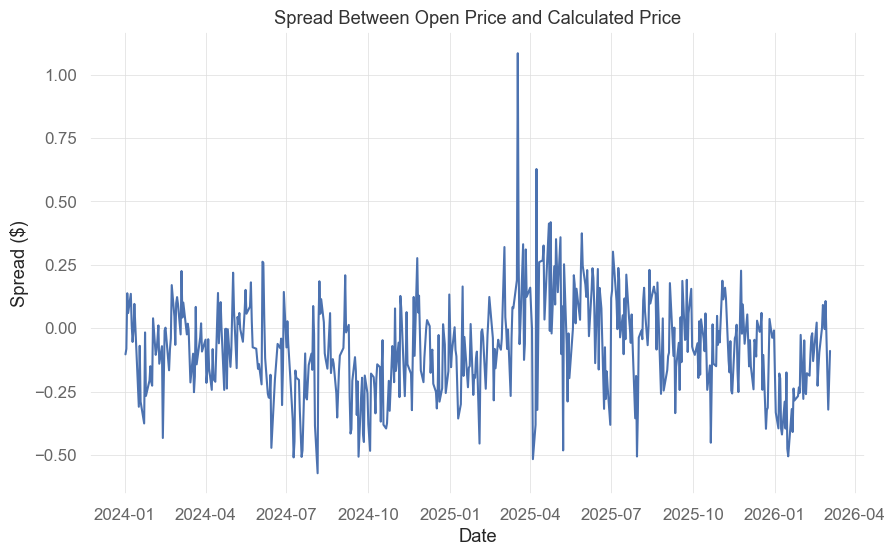

In [69]:
india_ticker = "ICICIBANK.NS"
us_ticker = "IBN"

india_data = yf.download(india_ticker, start="2024-01-01", end="2026-03-05", auto_adjust=True)
us_data = yf.download(us_ticker, start="2024-01-01", end="2026-03-05", auto_adjust=True)
fx_data = yf.download("USDINR=X", start="2024-01-01", end="2026-03-05", auto_adjust=True)

india_data.columns = india_data.columns.get_level_values(0)
us_data.columns = us_data.columns.get_level_values(0)
fx_data.columns = fx_data.columns.get_level_values(0)
india1_df = pd.DataFrame({
    'india_Close': india_data['Close'],
    'US_Open': us_data['Open'],
    'FX': fx_data['Close'],
    "US_Close": us_data["Close"],
    "US_High": us_data["High"],
    'US_Low': us_data["Low"]
}).dropna()
india1_df['Fair_Value_USD'] = (india1_df['india_Close'] * 2) / india1_df['FX']
india1_df['Spread india - US'] = india1_df['US_Open'] - india1_df['Fair_Value_USD']


plt.plot(india1_df["Spread india - US"])
plt.title("Spread Between Open Price and Calculated Price")
plt.xlabel("Date")
plt.ylabel("Spread ($)")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


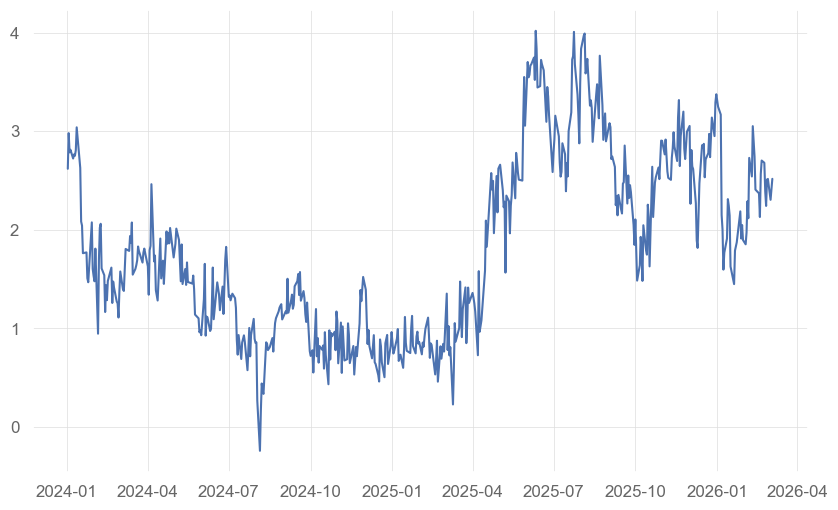

In [66]:
india_ticker = "HDFCBANK.NS"
us_ticker = "HDB"

india_data = yf.download(india_ticker, start="2024-01-01", end="2026-03-05", auto_adjust=True)
us_data = yf.download(us_ticker, start="2024-01-01", end="2026-03-05", auto_adjust=True)
fx_data = yf.download("USDINR=X", start="2024-01-01", end="2026-03-05", auto_adjust=True)

india_data.columns = india_data.columns.get_level_values(0)
us_data.columns = us_data.columns.get_level_values(0)
fx_data.columns = fx_data.columns.get_level_values(0)
india_df = pd.DataFrame({
    'india_Close': india_data['Close'],
    'US_Open': us_data['Open'],
    'FX': fx_data['Close'],
    'US_High': us_data["High"],
    'US_Low': us_data["Low"],
    'US_Close': us_data["Close"]
}).dropna()
india_df['Fair_Value_USD'] = (india_df['india_Close'] * 3) / india_df['FX']
india_df['Spread india - US'] = india_df['US_Open'] - india_df['Fair_Value_USD']


plt.plot(india_df["Spread india - US"])

0.06747157065932854


(array([ 2.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  2.,  2.,  1., 12.,  7.,
        11., 12., 14., 21., 21., 41., 78., 69., 47., 46., 27., 30., 17.,
        12.,  8.,  8.,  3.,  2.,  2.,  1.,  1.,  0.,  0.,  0.,  1.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([-0.83907547, -0.79464354, -0.75021161, -0.70577968, -0.66134775,
        -0.61691582, -0.57248389, -0.52805195, -0.48362002, -0.43918809,
        -0.39475616, -0.35032423, -0.3058923 , -0.26146037, -0.21702844,
        -0.17259651, -0.12816458, -0.08373265, -0.03930072,  0.00513122,
         0.04956315,  0.09399508,  0.13842701,  0.18285894,  0.22729087,
         0.2717228 ,  0.31615473,  0.36058666,  0.40501859,  0.44945052,
         0.49388245,  0.53831439,  0.58274632,  0.62717825,  0.67161018,
         0.71604211,  0.76047404,  0.80490597,  0.8493379 ,  0.89376983,
         0.93820176,  0.98263369,  1.02706563,  1.07149756,  1.11592949,
         1.16036142,  1.20479335,  1.24922528,  1.29365721,

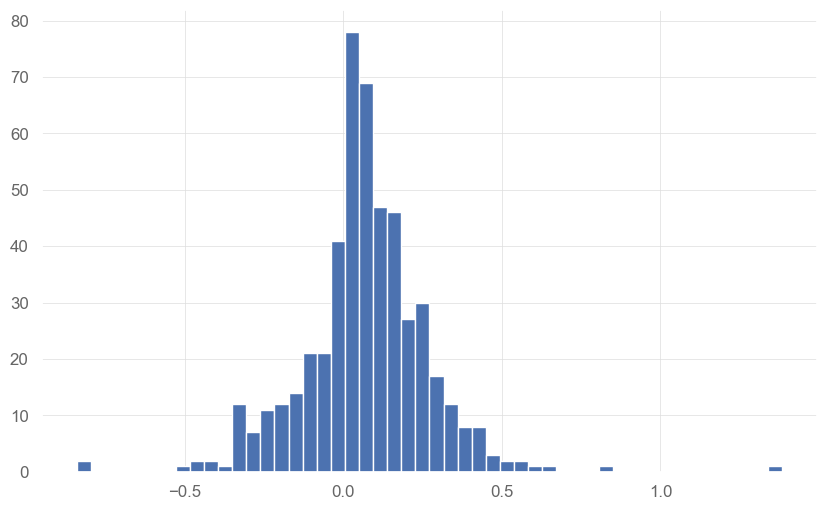

In [57]:
gain = []
for i in range(len(tw_df)):
    open_price = tw_df['US_Open'].iloc[i]
    close_price = tw_df['US_Close'].iloc[i]
    fair_value = tw_df['Fair_Value_USD'].iloc[i]
    spread = tw_df['Spread TW - US'].iloc[i]

    if tw_df["US_Low"].iloc[i] <= fair_value <= tw_df["US_High"].iloc[i]:
        payoff = abs(spread)
    else:
        if spread < 0:
            payoff = close_price - open_price
        else:
            payoff = open_price - close_price
    gain.append(payoff)
print(np.mean(gain))
plt.hist(gain, bins=50)

0.014374254413402577


(array([ 1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  1.,
         0.,  0.,  1.,  2.,  5.,  0.,  2.,  5.,  6.,  8.,  7., 11., 11.,
        16., 18., 27., 21., 19., 88., 74., 53., 39., 25., 26., 16., 14.,
         8.,  4.,  4.,  2.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([-1.03182339, -0.99862457, -0.96542576, -0.93222694, -0.89902813,
        -0.86582931, -0.83263049, -0.79943168, -0.76623286, -0.73303405,
        -0.69983523, -0.66663642, -0.6334376 , -0.60023879, -0.56703997,
        -0.53384115, -0.50064234, -0.46744352, -0.43424471, -0.40104589,
        -0.36784708, -0.33464826, -0.30144944, -0.26825063, -0.23505181,
        -0.201853  , -0.16865418, -0.13545537, -0.10225655, -0.06905774,
        -0.03585892, -0.0026601 ,  0.03053871,  0.06373753,  0.09693634,
         0.13013516,  0.16333397,  0.19653279,  0.2297316 ,  0.26293042,
         0.29612924,  0.32932805,  0.36252687,  0.39572568,  0.4289245 ,
         0.46212331,  0.49532213,  0.52852094,  0.56171976,

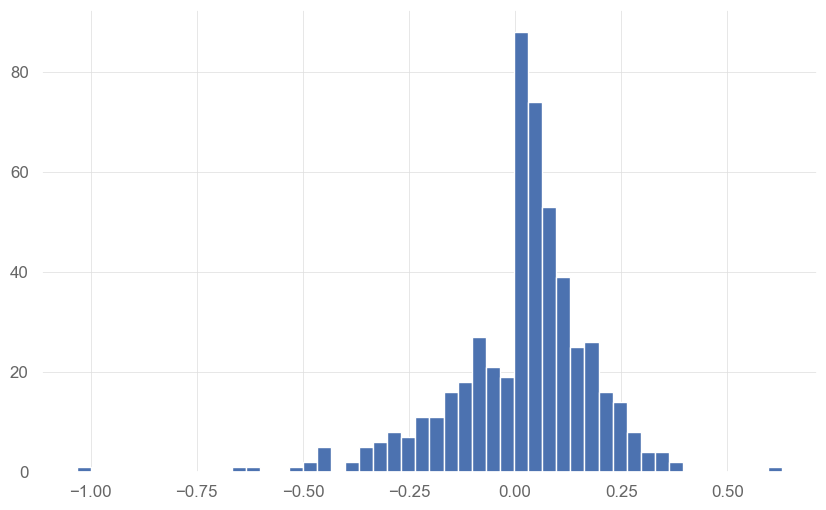

In [70]:
gain = []
for i in range(len(india1_df)):
    open_price = india1_df['US_Open'].iloc[i]
    close_price = india1_df['US_Close'].iloc[i]
    fair_value = india1_df['Fair_Value_USD'].iloc[i]
    spread = india1_df['Spread india - US'].iloc[i]

    if india1_df["US_Low"].iloc[i] <= fair_value <= india1_df["US_High"].iloc[i]:
        payoff = abs(spread)
    else:
        if spread < 0:
            payoff = close_price - open_price
        else:
            payoff = open_price - close_price
    gain.append(payoff)
print(np.mean(gain))
plt.hist(gain, bins=50)

NEW METHOD

In [82]:
brazil_ticker = "VALE3.SA"
us_ticker = "VALE"

brazil_data = yf.download(brazil_ticker, start="2025-01-01", end="2026-01-01", auto_adjust=True, interval = "1h")
us_data = yf.download(us_ticker, start="2024-01-01", end="2026-03-05", auto_adjust=True, interval = "1h")
fx_data = yf.download("BRLUSD=X", start="2024-01-01", end="2026-03-05", auto_adjust=True)

brazil_data.columns = brazil_data.columns.get_level_values(0)
us_data.columns = us_data.columns.get_level_values(0)
fx_data.columns = fx_data.columns.get_level_values(0)
brazil_data.index = brazil_data.index.tz_convert('UTC').tz_localize(None)
us_data.index = us_data.index.tz_convert('UTC').tz_localize(None)
fx_data.index = fx_data.index.tz_convert('UTC').tz_localize(None)
brazil_df = pd.DataFrame({
    'brazil_Close': brazil_data['Close'],
    'US_Open': us_data['Open'],
    'FX': fx_data['Close'],
    'US_High': us_data["High"],
    'US_Low': us_data["Low"],
    'US_Close': us_data["Close"]
}).dropna()


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['VALE']: YFPricesMissingError('possibly delisted; no price data found  (1h 2024-01-01 -> 2026-03-05) (Yahoo error = "1h data not available for startTime=1704085200 and endTime=1772686800. The requested range must be within the last 730 days.")')
[*********************100%***********************]  1 of 1 completed


TypeError: Cannot convert tz-naive timestamps, use tz_localize to localize

/var/folders/fp/93xv79yn301btyrjs9x_966h0000gn/T/ipykernel_87965/237464389.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, period="8d", interval="1m")
[*********************100%***********************]  3 of 3 completed


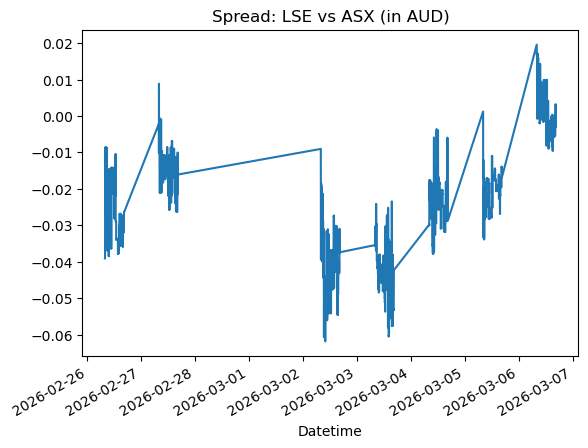

In [ ]:
tickers = ["A11.AX", "ALL.L", "GBPAUD=X"]
data = yf.download(tickers, period="8d", interval="1m")

london_tz = 'Europe/London'
brazil = data['Close']['A11.AX'].tz_convert(london_tz)
us = data['Close']['ALL.L'].tz_convert(london_tz)
fx = data['Close']['GBPAUD=X'].tz_convert(london_tz)

df = pd.DataFrame({
    'ASX_Close_AUD': brazil,
    'LSE_Close_GBX': us,
    'FX_Rate': fx
})

df = df.ffill()

df = df.between_time('08:00', '16:30')

df['LSE_Close_AUD'] = (df['LSE_Close_GBX'] / 100) * df['FX_Rate']
df['Spread'] = df['LSE_Close_AUD'] - df['ASX_Close_AUD']

# 6. Plot
df['Spread'].plot(title="Spread: LSE vs ASX (in AUD)")
plt.show()

# CDD

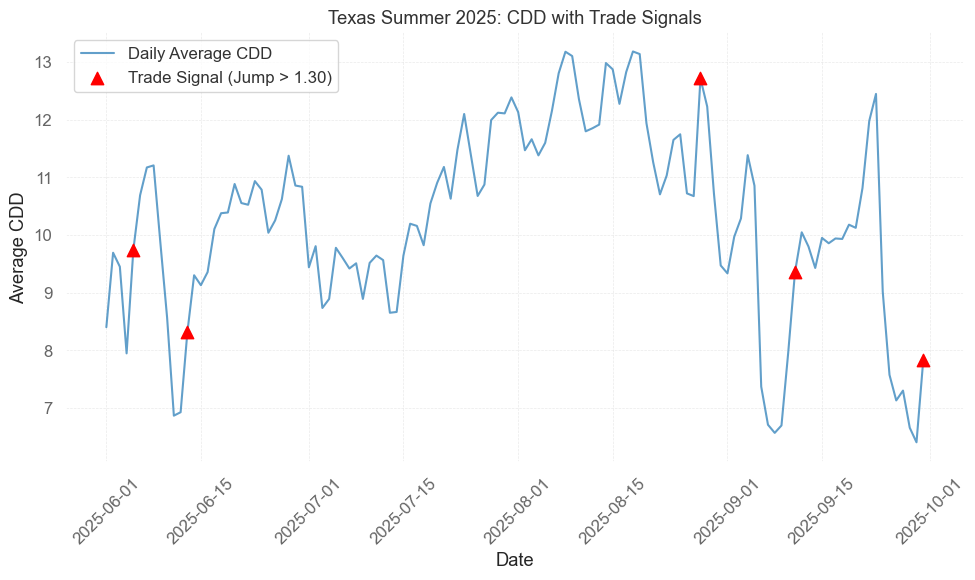

In [ ]:

cdds = pd.read_csv("summer_average_cdd.csv")
cdds['date'] = pd.to_datetime(cdds['date'])

std = np.std(cdds['avg_cdd'])
threshold = 0.8 * std

cdds['prev_avg_cdd'] = cdds['avg_cdd'].shift(1)
signals = cdds[cdds['avg_cdd'] > (threshold + cdds['prev_avg_cdd'])]

plt.figure(figsize=(10, 6))
plt.plot(cdds['date'], cdds['avg_cdd'], color='tab:blue', label='Daily Average CDD', alpha=0.7)

plt.scatter(signals['date'], signals['avg_cdd'],
                color='red', marker='^', s=80, label=f'Trade Signal (Jump > {threshold:.2f})', zorder=5)
plt.title(f'Texas Summer 2025: CDD with Trade Signals')
plt.xlabel('Date')
plt.ylabel('Average CDD')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

[*********************100%***********************]  1 of 1 completed


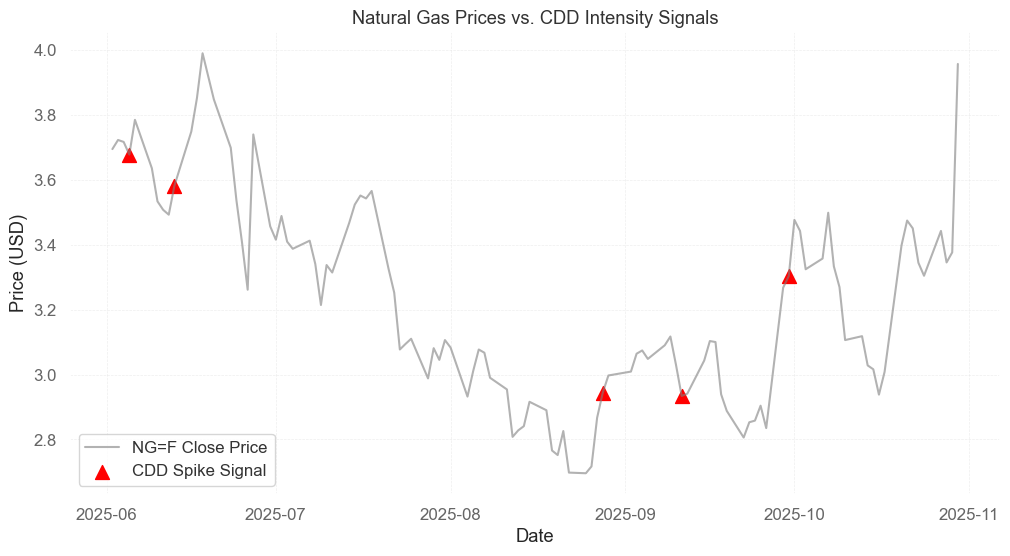

In [157]:
gas = yf.download("NG=F", start='2025-06-01', end='2025-10-31', auto_adjust=True)
gas_prices = gas['Close']
signal_dates = signals['date']
signal_prices = gas_prices.loc[gas_prices.index.intersection(signal_dates)]

plt.figure(figsize=(12, 6))
plt.plot(gas_prices.index, gas_prices.values, label='NG=F Close Price', color='gray', alpha=0.6)

plt.scatter(signal_prices.index, signal_prices.values,
            color='red', label='CDD Spike Signal', marker='^', s=100)
plt.title('Natural Gas Prices vs. CDD Intensity Signals')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


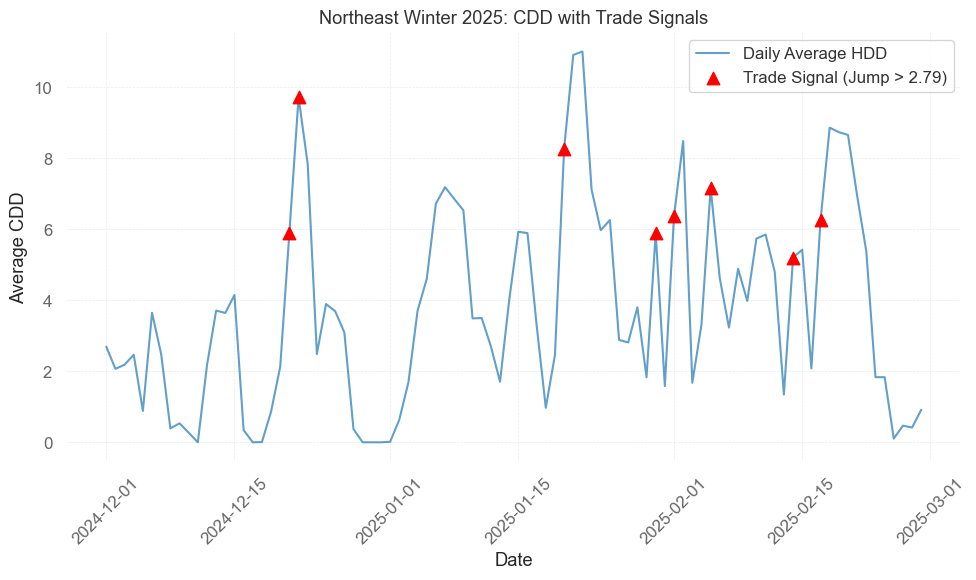

In [161]:

hdds = pd.read_csv("winter_average_hdd.csv")
hdds['date'] = pd.to_datetime(hdds['date'])

std = np.std(hdds['avg_hdd'])
threshold = 1 * std

hdds['prev_avg_hdd'] = hdds['avg_hdd'].shift(1)
signals = hdds[hdds['avg_hdd'] > (threshold + hdds['prev_avg_hdd'])]

plt.figure(figsize=(10, 6))
plt.plot(hdds['date'], hdds['avg_hdd'], color='tab:blue', label='Daily Average HDD', alpha=0.7)

plt.scatter(signals['date'], signals['avg_hdd'],
                color='red', marker='^', s=80, label=f'Trade Signal (Jump > {threshold:.2f})', zorder=5)
plt.title(f'Northeast Winter 2025: CDD with Trade Signals')
plt.xlabel('Date')
plt.ylabel('Average CDD')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

[*********************100%***********************]  1 of 1 completed


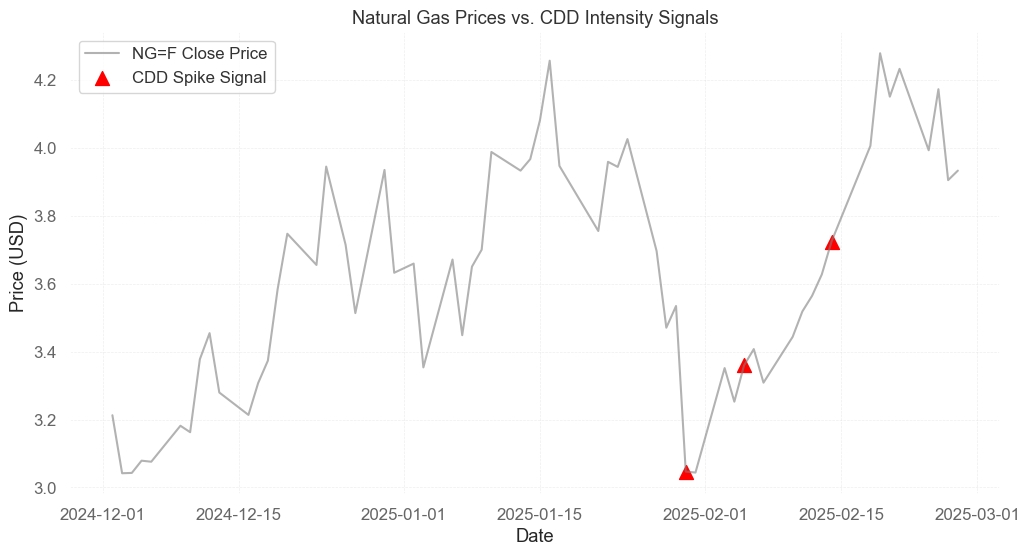

In [162]:
gas = yf.download("NG=F", start='2024-12-01', end='2025-02-28', auto_adjust=True)
gas_prices = gas['Close']
signal_dates = signals['date']
signal_prices = gas_prices.loc[gas_prices.index.intersection(signal_dates)]

plt.figure(figsize=(12, 6))
plt.plot(gas_prices.index, gas_prices.values, label='NG=F Close Price', color='gray', alpha=0.6)

plt.scatter(signal_prices.index, signal_prices.values,
            color='red', label='CDD Spike Signal', marker='^', s=100)
plt.title('Natural Gas Prices vs. CDD Intensity Signals')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


Lead Lag

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


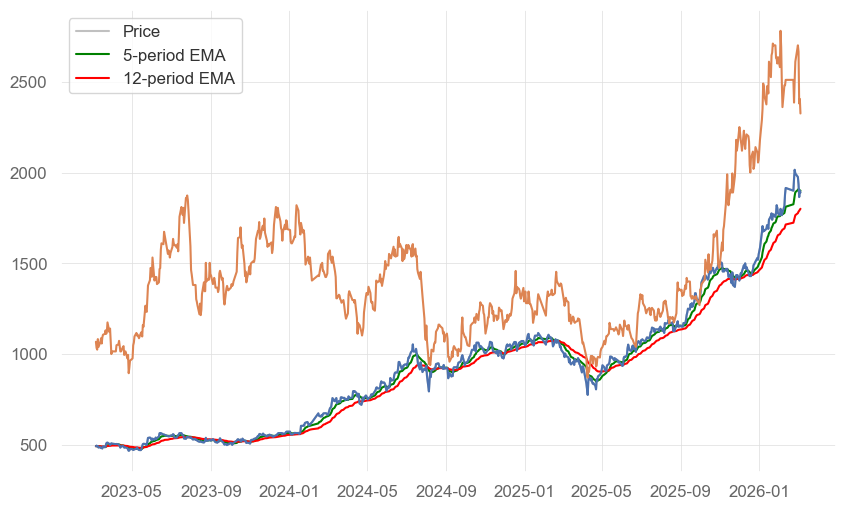

In [ ]:

tickers = ["2330.TW", "3443.TW"]
tsm = yf.download("2330.TW", period="3y", interval="1d", auto_adjust=True)['Close'].dropna()
umc = yf.download("3443.TW", period="3y", interval="1d", auto_adjust=True)['Open'].dropna()
ema12 = tsm.ewm(span=12, adjust=False).mean()
ema26 = tsm.ewm(span=36, adjust=False).mean()
plt.plot(tsm, label='Price', color='silver')
plt.plot(ema12, label='5-period EMA', color='green')
plt.plot(ema26, label='12-period EMA', color='red')

plt.legend()

plt.plot(tsm)
plt.plot(umc)

/var/folders/fp/93xv79yn301btyrjs9x_966h0000gn/T/ipykernel_52889/1613546404.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tsm = yf.download("2330.TW", period="2y", interval="1d")['Close'].squeeze().dropna()
[*********************100%***********************]  1 of 1 completed
/var/folders/fp/93xv79yn301btyrjs9x_966h0000gn/T/ipykernel_52889/1613546404.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  umc = yf.download("3443.TW", period="2y", interval="1d")['Close'].squeeze().dropna()
[*********************100%***********************]  1 of 1 completed


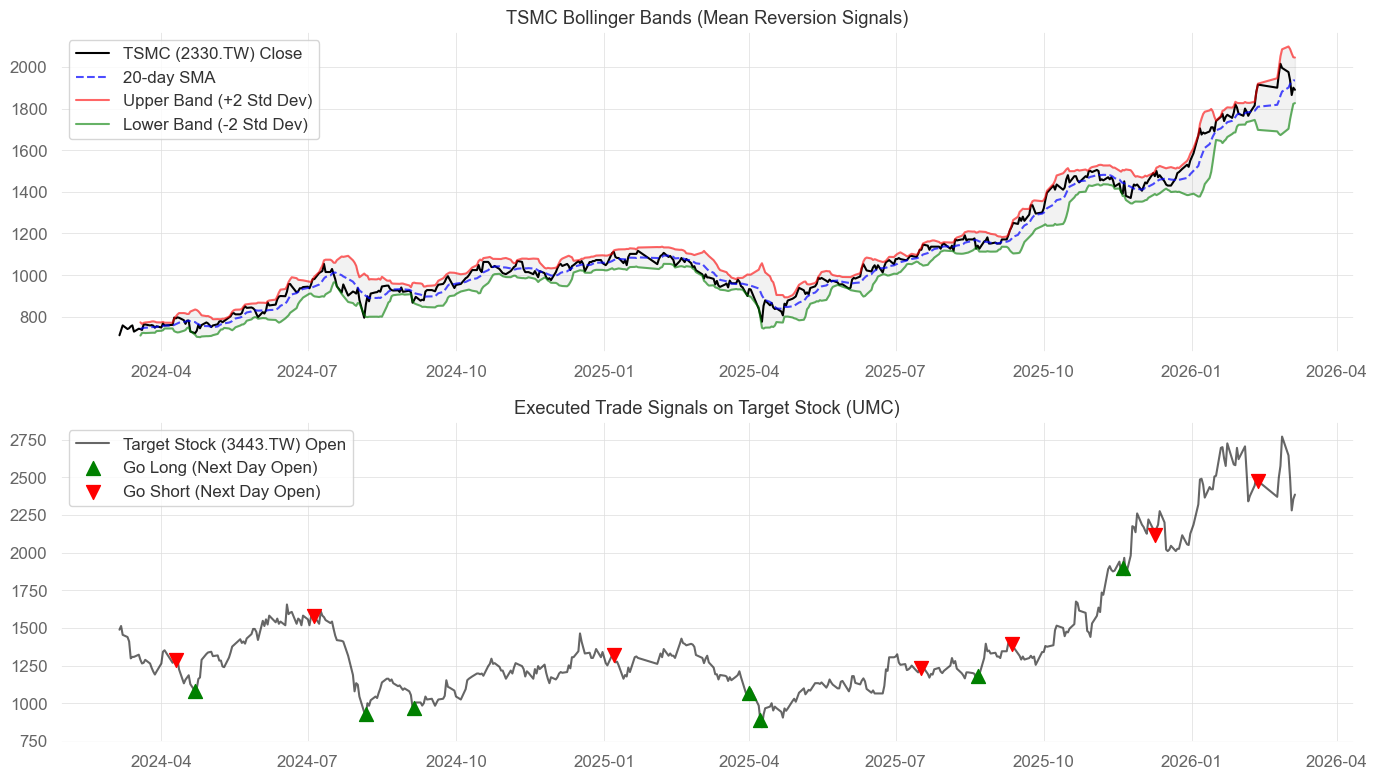

In [ ]:
tsm = yf.download("2330.TW", period="2y", interval="1d")['Close'].squeeze().dropna()
umc = yf.download("3443.TW", period="2y", interval="1d")['Close'].squeeze().dropna()

df = pd.DataFrame({'TSM_Close': tsm, 'UMC_Open': umc}).dropna()

window = 10
df['SMA20'] = df['TSM_Close'].rolling(window=window).mean()
df['STD20'] = df['TSM_Close'].rolling(window=window).std()

df['Upper_Band'] = df['SMA20'] + (df['STD20'] * 2.2)
df['Lower_Band'] = df['SMA20'] - (df['STD20'] * 2.2)

cross_below_lower = (df['TSM_Close'] < df['Lower_Band']) & (df['TSM_Close'].shift(1) >= df['Lower_Band'].shift(1))
cross_above_upper = (df['TSM_Close'] > df['Upper_Band']) & (df['TSM_Close'].shift(1) <= df['Upper_Band'].shift(1))

df['Signal'] = 0
df.loc[cross_below_lower, 'Signal'] = 1
df.loc[cross_above_upper, 'Signal'] = -1

df['Trade_Signal_UMC'] = df['Signal'].shift(1).fillna(0)

# 6. Plotting
plt.figure(figsize=(14, 8))

plt.subplot(2, 1, 1)
plt.plot(df.index, df['TSM_Close'], label='TSMC (2330.TW) Close', color='black', linewidth=1.5)
plt.plot(df.index, df['SMA20'], label='20-day SMA', color='blue', linestyle='--', alpha=0.7)
plt.plot(df.index, df['Upper_Band'], label='Upper Band (+2 Std Dev)', color='red', alpha=0.6)
plt.plot(df.index, df['Lower_Band'], label='Lower Band (-2 Std Dev)', color='green', alpha=0.6)

plt.fill_between(df.index, df['Lower_Band'], df['Upper_Band'], color='gray', alpha=0.1)

plt.title('TSMC Bollinger Bands (Mean Reversion Signals)')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(df.index, df['UMC_Open'], label='Target Stock (3443.TW) Open', color='black', alpha=0.6)

long_signals = df[df['Trade_Signal_UMC'] == 1]
short_signals = df[df['Trade_Signal_UMC'] == -1]

plt.scatter(long_signals.index, long_signals['UMC_Open'], marker='^', color='green', label='Go Long (Next Day Open)', s=100, zorder=5)
plt.scatter(short_signals.index, short_signals['UMC_Open'], marker='v', color='red', label='Go Short (Next Day Open)', s=100, zorder=5)
plt.title('Executed Trade Signals on Target Stock (UMC)')
plt.legend()

plt.tight_layout()
plt.show()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


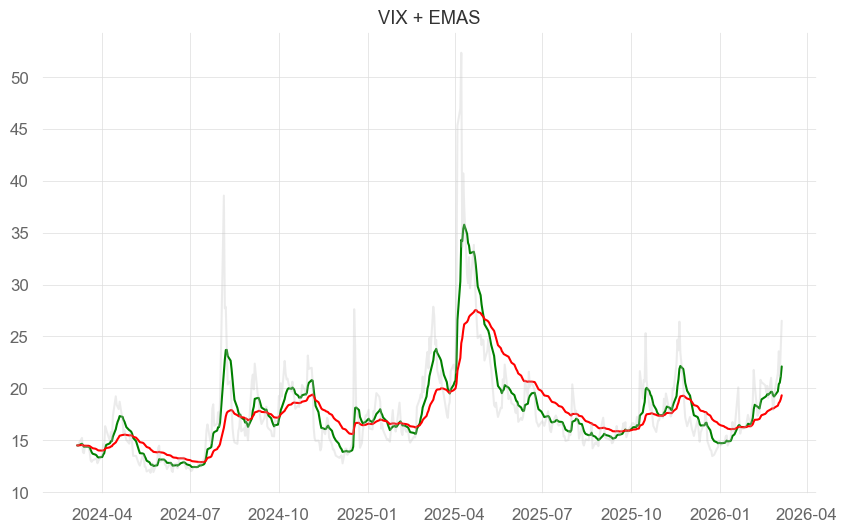

In [303]:
vix = yf.download("^VIX", period="2y", interval="1d", auto_adjust=True)['Close'].dropna()
spy = yf.download("SPY", period="2y", interval="1d", auto_adjust=True)['Close'].dropna()
ema12 = vix.ewm(span=10, adjust=False).mean()
ema26 = vix.ewm(span=40, adjust=False).mean()
plt.plot(ema12, label='6-period EMA', color='green')
plt.plot(ema26, label='12-period EMA', color='red')
plt.title("VIX + EMAS")
plt.plot(vix, color='silver', alpha=0.3)


/var/folders/fp/93xv79yn301btyrjs9x_966h0000gn/T/ipykernel_52889/3693083626.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  vix = yf.download("^VIX", period="3y")['Close'].dropna().squeeze()
[*********************100%***********************]  1 of 1 completed
/var/folders/fp/93xv79yn301btyrjs9x_966h0000gn/T/ipykernel_52889/3693083626.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gld = yf.download("GLD", period="3y")['Close'].dropna().squeeze()
[*********************100%***********************]  1 of 1 completed


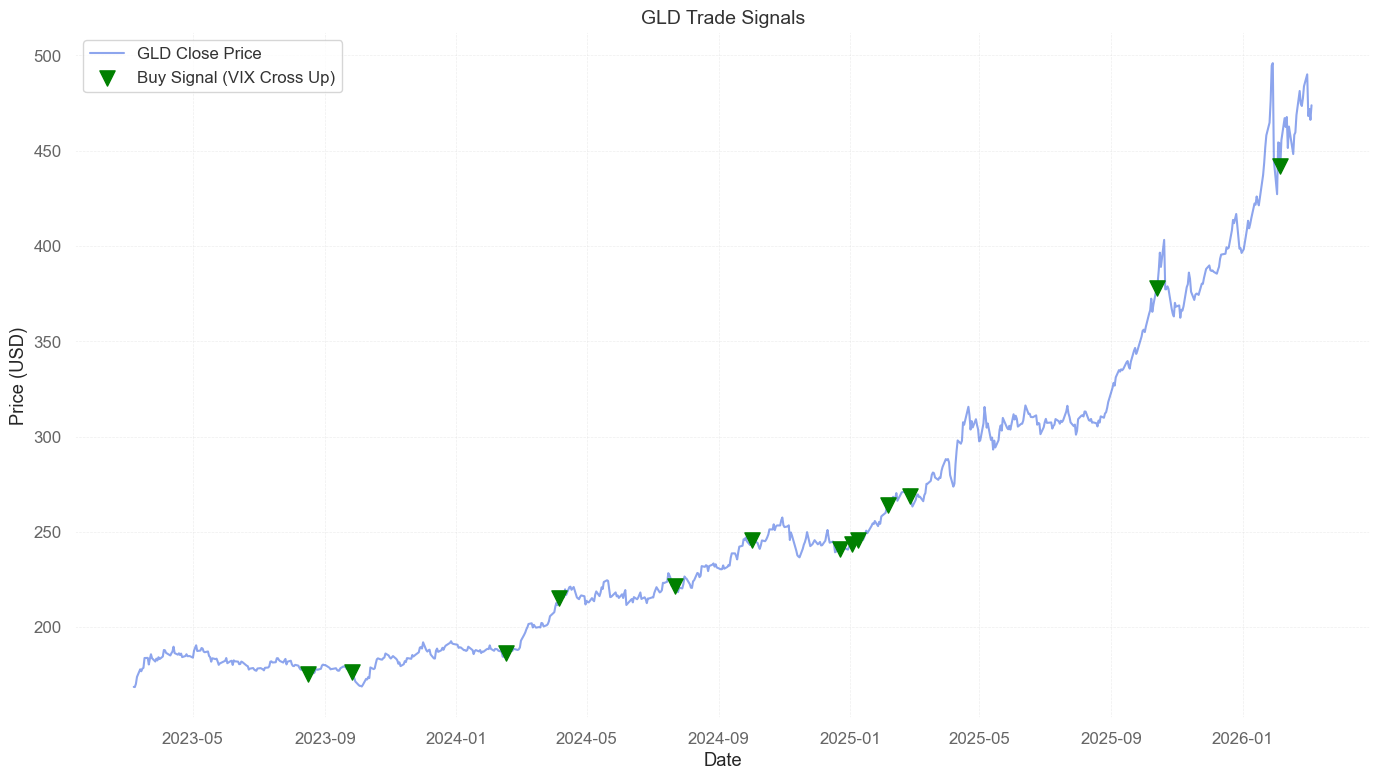

In [ ]:
vix = yf.download("^VIX", period="3y")['Close'].dropna().squeeze()
gld = yf.download("GLD", period="3y")['Close'].dropna().squeeze()

ema5 = vix.ewm(span=20, adjust=False).mean()
ema12 = vix.ewm(span=50, adjust=False).mean()

vix_signal = np.where(ema5 < ema12, 1, -1)

trade_signal = pd.Series(vix_signal, index=vix.index).shift(1)

df = pd.DataFrame({'GLD': gld, 'Signal': trade_signal}).dropna()

df['Signal_Change'] = df['Signal'].diff()
buys = df[df['Signal_Change'] == 2]
sells = df[df['Signal_Change'] == -2]

plt.figure(figsize=(14, 8))

plt.plot(df.index, df['GLD'], label='GLD Close Price', color='royalblue', alpha=0.6, linewidth=1.5)
'''
# Plot Buy Signals (Green Triangles)
plt.scatter(buys.index, buys['GLD'], marker='^', color='green', s=120, label='Buy Signal (VIX Cross Down)', zorder=5)
'''
plt.scatter(sells.index, sells['GLD'], marker='v', color='green', s=120, label='Buy Signal (VIX Cross Up)', zorder=5)

plt.title('GLD Trade Signals', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend(loc='best')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

/var/folders/fp/93xv79yn301btyrjs9x_966h0000gn/T/ipykernel_52889/2314480210.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  vix = yf.download("^VIX", period="3y")['Close'].dropna().squeeze()
[*********************100%***********************]  1 of 1 completed
/var/folders/fp/93xv79yn301btyrjs9x_966h0000gn/T/ipykernel_52889/2314480210.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy = yf.download("SPY", period="3y")['Close'].dropna().squeeze()
[*********************100%***********************]  1 of 1 completed


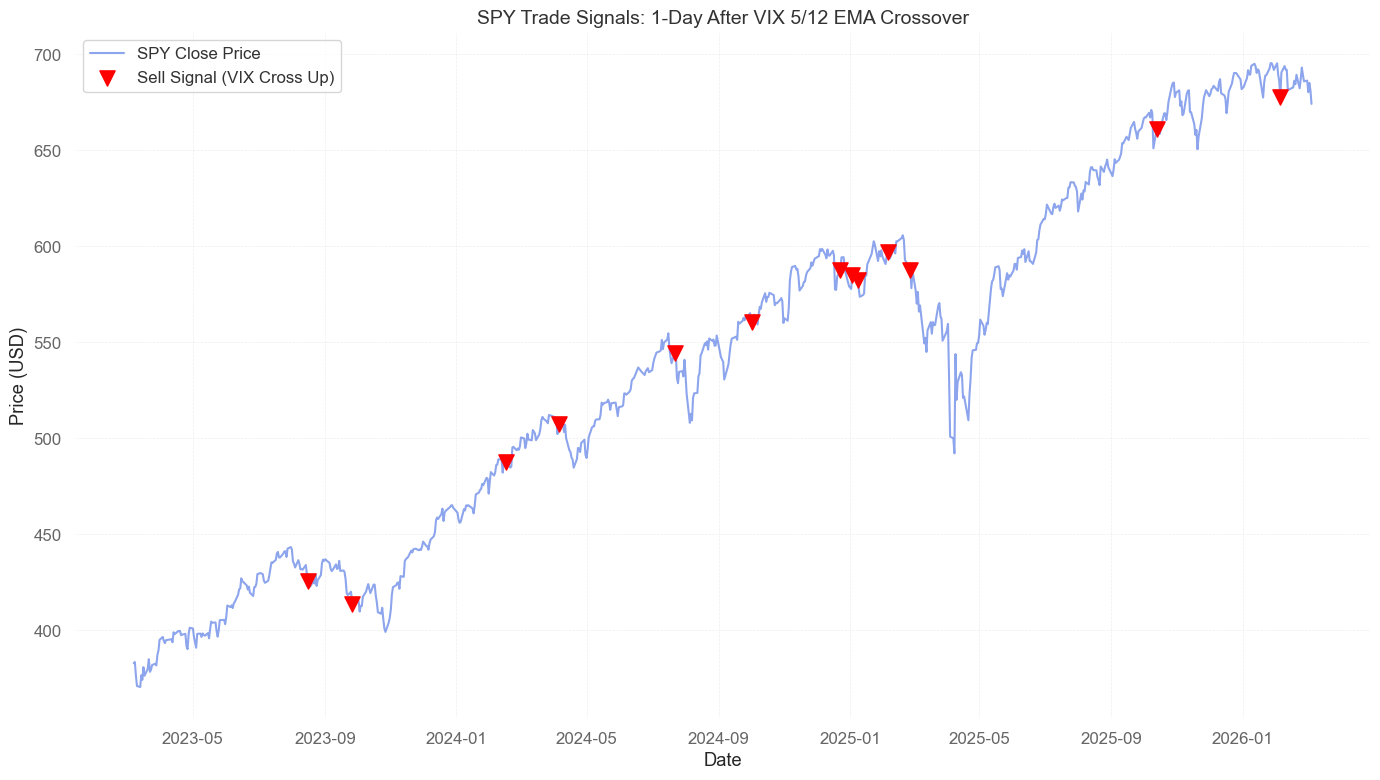

In [ ]:
vix = yf.download("^VIX", period="3y")['Close'].dropna().squeeze()
spy = yf.download("SPY", period="3y")['Close'].dropna().squeeze()

ema5 = vix.ewm(span=20, adjust=False).mean()
ema12 = vix.ewm(span=50, adjust=False).mean()

vix_signal = np.where(ema5 < ema12, 1, -1)

trade_signal = pd.Series(vix_signal, index=vix.index).shift(1)

df = pd.DataFrame({'SPY': spy, 'Signal': trade_signal}).dropna()

df['Signal_Change'] = df['Signal'].diff()
buys = df[df['Signal_Change'] == 2]
sells = df[df['Signal_Change'] == -2]

plt.figure(figsize=(14, 8))

plt.plot(df.index, df['SPY'], label='SPY Close Price', color='royalblue', alpha=0.6, linewidth=1.5)
'''
# Plot Buy Signals (Green Triangles)
plt.scatter(buys.index, buys['SPY'], marker='^', color='green', s=120, label='Buy Signal (VIX Cross Down)', zorder=5)
'''
plt.scatter(sells.index, sells['SPY'], marker='v', color='red', s=120, label='Sell Signal (VIX Cross Up)', zorder=5)

plt.title('SPY Trade Signals: 1-Day After VIX 5/12 EMA Crossover', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend(loc='best')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()